# Evaluation of the effect of Banco del Bienestar on Private Financial Infraestructure: A Dynamic Causal Study 2019-2022.

**Autor:** Mathias Alejandro Gómez Chan

**Email:** [mathias70473@gmail.com](mailto:mathias70473@gmail.com)

**GitHub:** [GitHub/Mathias-ds](https://github.com/Mathias70473)

**Date:** June 2026
---

## Objective.

>The following project has the main goal to determine wether the opening of Banco del Bienestar branches had a causal effect on the local private financial infrastructure (measured by financial correspondents) in treated municipalities. 

Because the program's purpose was to provide a public banking alternative rather than to expand the commercial financial system, the effect of opening a new branch could either expand local private financial services or reduce them. This effect is worth of study rather than just assume, since the direction of the spillover is not obvious in advance.

In a specific sense, Banco del Bienestar does pursue financial inclusion but, on it's own public channel rather than a private one which this study measures.


## Research Question.

>Will the Banco del Bienestar implementation have an effect in the financial infrastructure in a treated municipality?

Following the objective, in order to evaluate the effect of the opening a new branch, we need to compare two main groups: treated (municipality that received a branch) and untreated (municipality that never received a branch). This basic design idea, has the purpose to measure the effect of the branch with the private local infrastructure measured by corresponsales, corresponsales can be defined as an independent retail business that acts on behalf of a bank, so the design leads to a formal question: Does a branch opening lead to an increment of corresponsales or, a decrease?



In [29]:
# Library import

import pandas as pd #DataFrame Manipulation
import numpy as np # Math operations
from csdid.att_gt import ATTgt ## C-S estimation

## Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Data

The identification of the branches was possible through the quarterly report by the CNBV(Comisión Nacional Bancaria y de Valores): "Bases de Datos de Inclusión Financiera". The information provided covers different topics of financial inclusion but only the infrastructure per municipality section was used.

A total of 16 datasets were recovered, each one corresponding to one quarter of each year from 2019 to 2022.
In each dataset, it is displayed the corresponding information of the government supported banks also known as "Banca de Desarrollo" or development banks for direct translation, the report measures the financial outreach of these types of banks per municipality, although useful, it is important to mention that the information is the aggregate of different bank brands,  "Banco del Bienestar" is one of different banks for development supported by the government, another examples are: BANJERCITO, BANOBRAS... and so on.

The data panel was constructed using one municipality per row matching one specific quarter for report for a range of 2,463 - 2,472 municipalities per quarter for a total 39,459 total rows, meaning that for each municipality one specific quarter was assigned at time; the columns selected for the study were 21 and were the same across all reports however, manipulation was required for the final 2022 Q4, as the columns changed from previous reports.

The December 2022 report restructured the column layout into a multi-level header broken down by institution type (Banca múltiple, Banca de desarrollo, Socap, Sofipo), instead of the flat structure used in prior quarters. The relevant aggregate columns were mapped manually to match the schema of the other 15 reports before merging.

The key variable retained as the primary outcome is corresponsales, used to measure private financial infrastructure. sucursales_banca_de_desarrollo is used to construct the treatment indicator, and población and tipo_de_población serve as municipal-level context for the comparability checks described in the Identification Threats section.



In [30]:
## Data importation

df=pd.read_csv(r'../data/processed/panel.csv') #Treated CSV from CNBV reports
print(df.columns)
print('\n')
print('The dataframe shape is:', df.shape)

Index(['clave_municipio', 'clave_estado', 'región', 'estado', 'municipio',
       'población', 'población_adulta', 'población_adulta_mujeres',
       'población_adulta_hombres', 'tipo_de_población',
       'sucursales_banca_comercial', 'sucursales_banca_de_desarrollo',
       'sucursales_socap', 'sucursales_sofipo', 'total_sucursales',
       'corresponsales', 'cajeros', 'terminales_punto_de_venta',
       'establecimientos_con_tpv', 'contratos_que_utilizan_banca_móvil',
       'qrt'],
      dtype='str')


The dataframe shape is: (39459, 21)


## Treatment Definition

The treatment group is defined as municipalities that first recorded a Banco del Bienestar branch during 2022. Because the rollout was staggered, municipalities entered treatment in different quarters across the year; the design accounts for this by assigning each municipality its own treatment quarter rather than a single, shared treatment date. The nine municipalities identified as treated prior to 2022 were dropped, as their timing does not correspond to the main Banco del Bienestar expansion documented in news sources.


The selection of the branches was possible after cleaning and processing the data. Because the CNBV report aggregates all development banks into a single figure, branch counts recorded before 2019Q1 reflect legacy infrastructure from institutions such as BANJERCITO and BANOBRAS, none of which underwent comparable branch expansion during the study period. To isolate the Banco del Bienestar effect, treatment eligibility was restricted to municipalities with zero development-bank branches at the 2019Q1 baseline; municipalities with pre-existing branches remain in the panel but cannot be coded as treated. The main rollout took place across 2022, so the pre-treatment period covers all quarters before a municipality's first recorded branch, and the post-treatment period begins once that branch appears. Because the expansion unfolded across the four quarters of 2022 rather than all at once, the design accounts for staggered adoption: a municipality could enter treatment as early as 2022Q1 or as late as 2022Q4. Because the expansion unfolded across several months rather than all at once, the design accounts for staggered adoption: a municipality could be coded as treated as late as the second quarter of 2022 instead of all at once.

In [31]:
# Identification of legacy banks in the data.

## Municipalities with 0 -> 0
## Baseline for evaluation
baseline = df[df['qrt'] == 201903][['clave_municipio', 'sucursales_banca_de_desarrollo']]
zero_baseline = baseline[baseline['sucursales_banca_de_desarrollo'] == 0]['clave_municipio']
## Treated municipality with banca desarrllow above 2019-03
above = df[(df['qrt'] > 201903) & (df['sucursales_banca_de_desarrollo']>0)][['clave_municipio', 'municipio','qrt']]
merge=pd.merge(zero_baseline, above, on='clave_municipio', how='inner')
final=merge.groupby('clave_municipio')['qrt'].min().reset_index()

print(final['qrt'].value_counts().sort_index())

qrt
201906      3
202006      1
202009      1
202103      3
202112      1
202203    186
202206     93
202209    111
202212     76
Name: count, dtype: int64


In [32]:
## Municipality never treated
never_treated = zero_baseline[~zero_baseline.isin(final['clave_municipio'])]

## Removing 9 municipalities treated before 202203
treated_2022 = final[final['qrt'] >= 202203]

## Create final df with treated and untreated municipalities
study_municipalities = pd.concat([
    treated_2022[['clave_municipio']].assign(treated=1),
    never_treated.to_frame().assign(treated=0)
])

df_study= pd.merge(df, study_municipalities, on='clave_municipio', how='inner')
first_treated = treated_2022.rename(columns={'qrt':'first_treated_qrt'})
df_study=pd.merge(df_study, first_treated, on='clave_municipio', how='left')

print(df_study.columns)
print('Final Shape of the  Study df:', df_study.shape)



Index(['clave_municipio', 'clave_estado', 'región', 'estado', 'municipio',
       'población', 'población_adulta', 'población_adulta_mujeres',
       'población_adulta_hombres', 'tipo_de_población',
       'sucursales_banca_comercial', 'sucursales_banca_de_desarrollo',
       'sucursales_socap', 'sucursales_sofipo', 'total_sucursales',
       'corresponsales', 'cajeros', 'terminales_punto_de_venta',
       'establecimientos_con_tpv', 'contratos_que_utilizan_banca_móvil', 'qrt',
       'treated', 'first_treated_qrt'],
      dtype='str')
Final Shape of the  Study df: (31344, 23)


## Identification Strategy.

In order to correctly evaluate the effect of the branch opening it was needed to subtract the effect of confounder variables, estimate the counterfactual effect for treated municipalities and measure if the growth of corresponsales with and without treatment, is fairly similar among municipalities. A dream solution would be to randomize the treatment assignment but in practice this is impossible, instead it can be tested with a difference on differences approach (DiD).

In this scenario, the parallel trends assumption between municipalities treated and untreated is required to accurately determine the effects of the treatment and, avoid bias from the timing of the rollout. This is important to ensure that in the absence of treatment, treated and control municipalities would have followed a similar trend over time.

As the branch opening  does not happen at a single period, different cohorts of expansion should be treated with caution as, we cannot mix untreated municipalities with treated ones. For this reason, we can use a Callaway-Sant'Anna approach to study the effect of the treatment on different quarters, the technique allows to compare treated municipalities with never treated ones and, depending on the quarter with municipalities yet to be treated, this is much helpful as the treatment effects can be better presented in the long term.

## Identification Threats.

Identifying potential risks to the study is key to understand the results and measure if these are credible or not. Underlying details have been found and reported that might affect the final interpretation.

The first threat identified is that, the branches are deployed in mainly in semi-urban or urban municipalities. A common misconception is that the branches would be deployed in less developed areas so it could present an alternative for municipalities with very few banking options but, in reality the deployment started in municipalities with more development. As shown in the trend plot (***Results and interpretation section***), treated municipalities are around 3 times larger/more developed than untreated municipalities. This was addressed using logs transformation which resolved the scale artifact; parallel trends held after the transformation, and the result was robust across never-treated and not-yet-treated control groups.  

**Baseline comparability (2019Q1):**

| | Control (n=1,493) | Treated (n=466) |
|---|---|---|
| Mean population | 15,534 | 35,317 |
| Median population | 7,031 | 20,839 |
| % Rural | 40.6% | 9.4% |
| % Semi-urbano | 23.9% | 44.8% |
| % Urbano | 4.9% | 17.8% |

Treated municipalities are, on average, more than twice as populous as control municipalities at baseline, and the composition by population type differs sharply: control municipalities are predominantly rural (40.6%), while treated municipalities are concentrated in semi-urban and urban categories. This confirms that Banco del Bienestar placement was not random with respect to municipal development, and is the empirical basis for the parallel trends concern addressed via the log transformation in the Results section.

The second identified threat is the misclassification in the datasets, as previously discussed in the data section, the development banks are reported as an aggregate number each quarter without differentiation of each label (BANOBRAS, BANJERCITO...); before the study's evaluation it is possible to identify that these types of banks are fairly stable and with no big expansion so, we are considering that the increment in these numbers are highly related to the Banco del Bienestar.

The third threat is that corresponsales growth could partly reflect private banks expanding on their own, independent of Banco del Bienestar. This study can't fully separate two possibilities: private infrastructure following the branch opening (part of the crowd-in effect, and not a problem) versus private infrastructure expanding regardless of treatment (a genuine confounder). This limitation is acknowledged here rather than resolved.

## Results and interpretation.

### Trend plot evaluation.
Before applying any DiD application, it is required to confirm that the trends for treated and untreated municipalities are parallel and similar before treatment, for this reason, a lineplot was used as a direct method to ensure that both trends are similar. The results show that the trend for both groups is fairly similar however, we can see that the number of corresponsales in the treated group is around 3 times higher than untreated which, can hide a different trend with the current scale.

For a better visualization, it was applied a log transformation to the lineplot, which will change the interpretation from integers to percentage change. This transformation of the scale, allowed the distance of trend lines to shrink, allowing the better visualization of the general trend for both groups which are parallel.

### Event study estimation.

After visual confirmation, the Callaway-Sant'Anna estimator was applied to formally test whether the parallel trends assumption holds and to estimate the Average Treatment Effect (ATT) — the overall measure of the treatment's effect on corresponsales.

Three iterations were run to test and refine this result, described below with interpretation added underneath each.

#### **Full-window estimation (CS2)**

Overall ATT: -0.0057 (SE = 0.0083, 95% CI: [-0.0218, 0.0105])

Five pre-treatment event times were statistically significant: -12 (+0.0153), -10 (+0.0097), -9 (+0.0102), -7 (-0.0126), and -5 (-0.0207). All post-treatment event times (0, 1, 2, 3) were insignificant.

*Interpretation:* The initial results considered the full scope of the data for all quarters which led to low ATT (-0.0057) showing little to no effect on the corresponsales. This is also shown in the dynamic table where the four post-treatment effects were insignificant.

It is important to mention that most of the pre-treatment events were insignificant except: -12, -10, -9, -7 and -5. This represents a different pattern far from the treatment application, in order to test whether the ATT is sensitive to the inclusion of these distant pre-treatment periods, another estimation was run on a restricted sample.

#### **Shorter pre-window estimation (CS3)**

The sample was restricted to time ≥ 7 (dropping the earliest 6 quarters) and the model was re-estimated on this shorter panel, rather than simply changing the display window of the same estimate.

Overall ATT: -0.0057 (SE = 0.0080, 95% CI: [-0.0213, 0.0100])

Two pre-treatment event times remained significant: -7 (-0.0343) and -5 (-0.0207). The four periods closest to treatment (-4, -3, -2, -1) were all flat and insignificant.

*Interpretation:* 6 pre-treatment periods were excluded from the second test, however, the ATT stayed at the same level (-0.0057), which still shows no detectable effect from the treatment. The significance of the periods changed to -5 (-0.0207) & -7 (-0.0343). 

Because the periods immediately preceding treatment (-4 to -1) are flat and insignificant, the parallel trends assumption holds precisely where it matters most for identification, since these are the periods closest to the counterfactual.

The figure below provides visual confirmation of this pattern. Significant deviations are confined to distant pre-periods, while the boundary periods and the entire post-treatment window are statistically indistinguishable from zero.

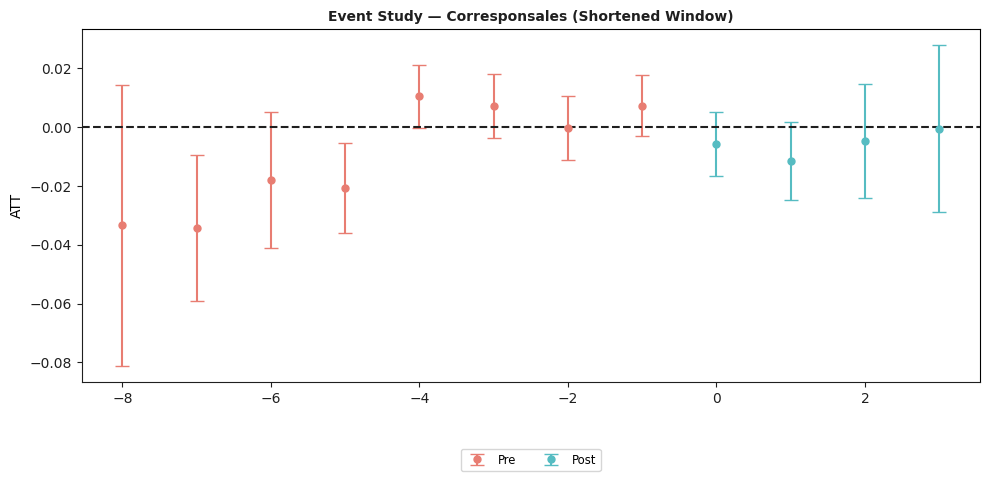

One final revision was checked with only not-yet-treated controls for robustness check.

#### **Robustness check — not-yet-treated controls (CS4)**

Overall ATT: -0.0058 (SE = 0.0079, 95% CI: [-0.0213, 0.0097])

Nearly identical to CS3 across every event time. The same two pre-periods (-7: -0.0287 and -5: -0.0188) remained significant; all others, including the boundary periods, stayed flat and insignificant.

*Interpretation:* For a final revision with only not-yet-treated municipalities, shows very similar effects, with an ATT of -0.0058 and significance remaining at -7 (-0.0287) and -5 (-0.0188), close to the CS3 values. This shows no statistically significant effect of the treatment on the number of corresponsales.

### Final results summarize.

The treatment was not statistically significant across all three estimations, the ATT had very similar values among three tests (-0.0057 and -0.0058) whether the control group was defined as never-treated or not-yet-treated municipalities. It is further supported by the behavior of the periods immediately preceding treatment, which showed flat, insignificant pre-trends consistent with a sound identification strategy.

With respect to the original research question, this finding provides no evidence that the Banco del Bienestar implementation had an effect, neither a crowd-in effect (private infrastructure expanding alongside the public branch) nor a crowd-out effect (private infrastructure retreating) is supported by the data. 

      qrt  treated  corresponsales str_qrt  corresponsales_log    Group
0  201903        0        4.221031  201903            1.440080  Control
1  201903        1       10.145923  201903            2.317072  Treated
2  201906        0        4.297388  201906            1.458007  Control
3  201906        1       10.302575  201906            2.332394  Treated
4  201909        0        4.630944  201909            1.532761  Control


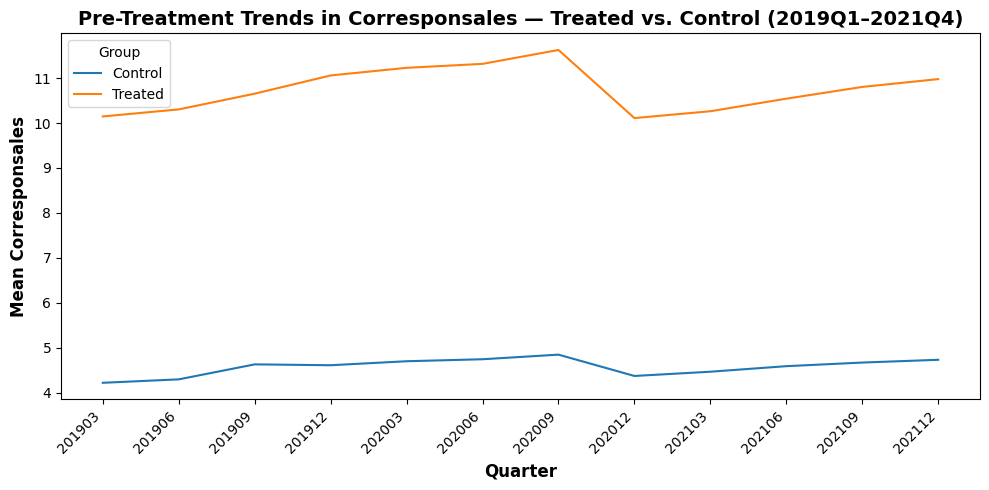

      qrt  treated  corresponsales_log str_qrt    Group
0  201903        0            0.895501  201903  Control
1  201903        1            1.751813  201903  Treated
2  201906        0            0.899954  201906  Control
3  201906        1            1.751853  201906  Treated
4  201909        0            0.926419  201909  Control


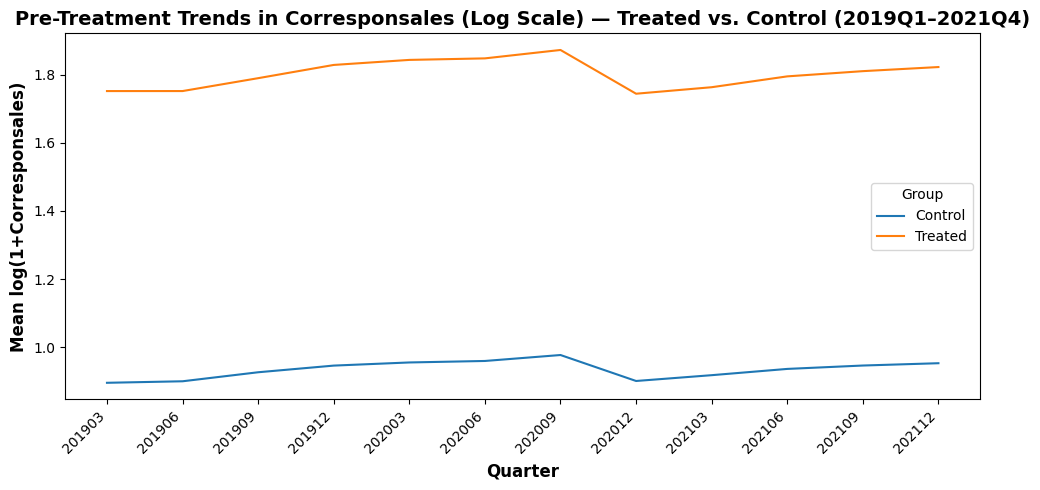

In [33]:
## Trend plot for treated and untreated prev

prev_trend=df_study[df_study['qrt']<202203]
prev_trend=prev_trend.groupby(by=['qrt', 'treated'])['corresponsales'].agg('mean').reset_index()
prev_trend['str_qrt']=prev_trend['qrt'].astype('str')
prev_trend['corresponsales_log']=np.log(prev_trend['corresponsales'])
prev_trend['Group'] = prev_trend['treated'].map({0: 'Control', 1: 'Treated'})
print(prev_trend.head())


## Plot with not log

plt.figure(figsize=[10,5])
sns.lineplot(x='str_qrt', y='corresponsales', data=prev_trend, hue='Group')
plt.title('Pre-Treatment Trends in Corresponsales — Treated vs. Control (2019Q1–2021Q4)', fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=12, fontweight='bold')
plt.ylabel('Mean Corresponsales', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Plot with log

prev_trend_log=df_study[df_study['qrt']<202203].copy()
prev_trend_log['corresponsales_log']=np.log1p(prev_trend_log['corresponsales'])
prev_trend_log=prev_trend_log.groupby(by=['qrt', 'treated'])['corresponsales_log'].agg('mean').reset_index()
prev_trend_log['str_qrt']=prev_trend_log['qrt'].astype('str')
prev_trend_log['Group'] = prev_trend_log['treated'].map({0: 'Control', 1: 'Treated'})
print(prev_trend_log.head())


plt.figure(figsize=[10,5])
sns.lineplot(x='str_qrt', y='corresponsales_log', data=prev_trend_log, hue='Group')
plt.title('Pre-Treatment Trends in Corresponsales (Log Scale) — Treated vs. Control (2019Q1–2021Q4)', fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=12, fontweight='bold')
plt.ylabel('Mean log(1+Corresponsales)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
## Data structure for C-S estimator, cleaning the data for csdid:

## Replace Null values with 0 for estimation.
df_study['g'] = df_study['first_treated_qrt'].fillna(0).astype(int)

# Create sequential time variable
qrt_mapping = {q: i+1 for i, q in enumerate(sorted(df_study['qrt'].unique()))}
df_study['time'] = df_study['qrt'].map(qrt_mapping)

# Also convert g to sequential time
g_mapping = {0: 0}  # never-treated stays 0
g_mapping.update({q: i+1 for i, q in enumerate(sorted(df_study['qrt'].unique()))})
df_study['g_seq'] = df_study['g'].map(g_mapping)

# Applying log adjustment to corresponsales to manage the difference in scale, interpretation on %
df_study['corresponsales_log']= np.log1p(df_study['corresponsales'])

print(qrt_mapping)
print(df_study[['qrt', 'time', 'g', 'g_seq', 'corresponsales_log']].head(20))

{np.int64(201903): 1, np.int64(201906): 2, np.int64(201909): 3, np.int64(201912): 4, np.int64(202003): 5, np.int64(202006): 6, np.int64(202009): 7, np.int64(202012): 8, np.int64(202103): 9, np.int64(202106): 10, np.int64(202109): 11, np.int64(202112): 12, np.int64(202203): 13, np.int64(202206): 14, np.int64(202209): 15, np.int64(202212): 16}
       qrt  time       g  g_seq  corresponsales_log
0   201903     1  202203     13            1.945910
1   201903     1  202203     13            3.178054
2   201903     1  202206     14            1.791759
3   201903     1       0      0            3.828641
4   201903     1  202203     13            2.772589
5   201903     1  202206     14            2.833213
6   201903     1  202206     14            1.386294
7   201903     1       0      0            2.302585
8   201903     1       0      0            1.386294
9   201903     1       0      0            3.044522
10  201903     1  202209     15            4.127134
11  201903     1       0      0 

In [35]:
## Callaway-Sant'Anna estimation, full dataset evaluation (full window).
cs2 = ATTgt(
    yname='corresponsales_log',
    tname='time',
    idname='clave_municipio',
    gname='g_seq',
    data=df_study
)
np.random.seed(42)
cs2.fit()
cs2.aggte(typec='dynamic')



Overall summary of ATT's based on event-study/dynamic aggregation:
    ATT Std. Error  [95.0%  Conf. Int.] 
-0.0057     0.0083 -0.0218       0.0105 


Dynamic Effects:
    Event time  Estimate  Std. Error  [95.0% Simult.   Conf. Band   
0          -14   -0.0202      0.0255          -0.0701      0.0298   
1          -13    0.0138      0.0082          -0.0023      0.0299   
2          -12    0.0153      0.0067           0.0022      0.0285  *
3          -11    0.0002      0.0072          -0.0140      0.0144   
4          -10    0.0097      0.0041           0.0017      0.0177  *
5           -9    0.0102      0.0035           0.0033      0.0171  *
6           -8   -0.0033      0.0053          -0.0137      0.0072   
7           -7   -0.0126      0.0055          -0.0234     -0.0019  *
8           -6   -0.0066      0.0077          -0.0217      0.0085   
9           -5   -0.0207      0.0082          -0.0369     -0.0046  *
10          -4    0.0105      0.0056          -0.0005      0.0214   
11



Overall summary of ATT's based on event-study/dynamic aggregation:
    ATT Std. Error  [95.0%  Conf. Int.] 
-0.0057      0.008 -0.0213         0.01 


Dynamic Effects:
    Event time  Estimate  Std. Error  [95.0% Simult.   Conf. Band   
0           -8   -0.0334      0.0243          -0.0811      0.0143   
1           -7   -0.0343      0.0127          -0.0591     -0.0094  *
2           -6   -0.0180      0.0118          -0.0410      0.0051   
3           -5   -0.0207      0.0078          -0.0360     -0.0055  *
4           -4    0.0105      0.0054          -0.0002      0.0211   
5           -3    0.0071      0.0056          -0.0039      0.0181   
6           -2   -0.0003      0.0056          -0.0112      0.0107   
7           -1    0.0073      0.0053          -0.0031      0.0176   
8            0   -0.0058      0.0056          -0.0168      0.0052   
9            1   -0.0116      0.0068          -0.0249      0.0017   
10           2   -0.0047      0.0099          -0.0241      0.0147   
11

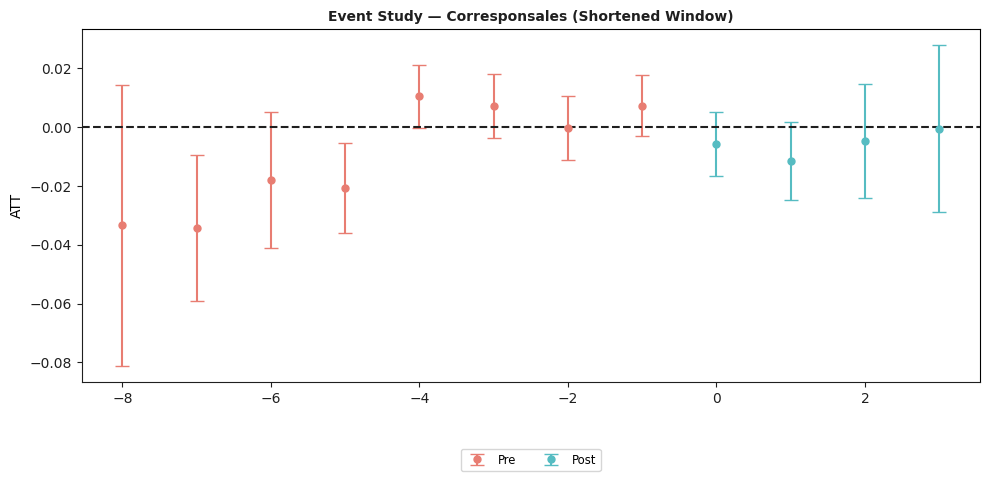

<Axes: title={'center': 'Event Study — Corresponsales (Shortened Window)'}, ylabel='ATT'>

In [36]:
## Shorter pre-window re-estimation Callaway-Sant'Anna (shorter window).
### Considering the significance is not presented in 5 Events with not a clear pattern. I am willing to test again with a shorter pre-window re-estimation.
### Drop the earliest 6 quarters (time 1-6 / 201903-202006) from the sample entirely.
### This makes the earliest cohort's first observed pre-period start at event time -6, matching the window we were previously only displaying.

df_short = df_study[df_study['time'] >= 7].copy()

cs3 = ATTgt(
    yname='corresponsales_log',
    tname='time',
    idname='clave_municipio',
    gname='g_seq',
    data=df_short
)
np.random.seed(42)
cs3.fit()
cs3.aggte(typec='dynamic')
cs3.plot_aggte(title='Event Study — Corresponsales (Shortened Window)', ref_line=0)

In [37]:
## ATT compare with pre-period pattern against never-treated (Robustness check, not-yet-treated controls)
cs4 = ATTgt(
    yname='corresponsales_log',
    tname='time',
    idname='clave_municipio',
    gname='g_seq',
    data=df_short,
    control_group='notyettreated'
)
np.random.seed(42)
cs4.fit()
cs4.aggte(typec='dynamic')



Overall summary of ATT's based on event-study/dynamic aggregation:
    ATT Std. Error  [95.0%  Conf. Int.] 
-0.0058     0.0079 -0.0213       0.0097 


Dynamic Effects:
    Event time  Estimate  Std. Error  [95.0% Simult.   Conf. Band   
0           -8   -0.0218      0.0247          -0.0703      0.0267   
1           -7   -0.0287      0.0126          -0.0534     -0.0039  *
2           -6   -0.0156      0.0119          -0.0389      0.0076   
3           -5   -0.0188      0.0075          -0.0335     -0.0040  *
4           -4    0.0098      0.0054          -0.0009      0.0204   
5           -3    0.0060      0.0057          -0.0051      0.0171   
6           -2   -0.0010      0.0054          -0.0116      0.0096   
7           -1    0.0073      0.0053          -0.0031      0.0178   
8            0   -0.0056      0.0054          -0.0163      0.0051   
9            1   -0.0116      0.0069          -0.0253      0.0020   
10           2   -0.0054      0.0100          -0.0249      0.0142   
11

## Limitations.

Several limitations should be acknowledged when interpreting these results.
First, the post-treatment window available in this panel is short. The earliest treated cohort (2022Q1) is observed for only four post-treatment quarters, while the latest cohort (2022Q4) has no post-treatment observations at all within the current data. The null result reported here therefore speaks only to short-run dynamics; it does not rule out effects that might emerge over a longer horizon. Extending the panel through 2023 is identified as a natural next step and is left for future work.

Second, the treatment variable is constructed from a column that aggregates all development banks operating in Mexico, including institutions such as BANJERCITO and BANOBRAS alongside Banco del Bienestar. While available evidence indicates that these other institutions did not undergo comparable branch expansion during the study period, the data does not allow individual branches to be attributed to a specific institution with certainty. The treatment indicator should therefore be understood as a close proxy for the Banco del Bienestar rollout rather than a direct, institution-level measure.

Third, because the outcome variable (corresponsales) reflects privately operated infrastructure, this study cannot fully distinguish between private infrastructure that expanded in response to the public branch opening and private infrastructure that would have expanded regardless of treatment. This limitation is inherent to the outcome choice and is disclosed rather than resolved.

Fourth, given that the estimated effect is null, formal sensitivity analysis would confirm what the data already suggests: there is little positive effect to protect from being explained away by pre-trend violations. Nonetheless, this remains a worthwhile addition for a future version, both as a methodological completeness step and to formally rule out alternative explanations for the observed pre-period noise.

Finally, this analysis considers a single outcome variable. Other dimensions of private financial infrastructure, such as point-of-sale terminals, were not evaluated here and are left as a direction for future work.

## Conclusion.

The study examined whether the 2022 expansion of Banco del Bienestar branches had a causal effect on private infrastructure, measured through the number of corresponsales, in municipalities with no previous development bank. Using a staggered Difference-in-Differences design with the Callaway-Sant'Anna estimator, the analysis found no statistically significant effect, this result is consistent among three estimations and robust to two different control group definitions.

The identification strategy was carefully evaluated before the conclusion was reached. Pre-treatment trends were flat and insignificant in the periods immediately preceding treatment. Three identification threats were considered: the systematic difference in baseline size between treated and control municipalities, the inability to isolate Banco del Bienestar from other aggregated development banks in the treatment variable, and the possibility that private infrastructure expansion was occurring independently of the public branch openings.

The outcome of the model with null finding shows that, within the four quarters following treatment observed in this panel, there is no evidence that Banco del Bienestar branches displaced or attracted private financial infrastructure in the municipalities where they opened, this is considering at least in the short period of evaluation, the public and private financial inclusion channels examined here operated independently of one another.